In [1]:
!git clone https://github.com/NguyenVH01/Vision-Mamba-demo.git

Cloning into 'Vision-Mamba-demo'...
remote: Enumerating objects: 4, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 4 (delta 0), reused 4 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (4/4), done.


In [2]:
%cd Vision-Mamba-demo
!pip install -r requirements.txt

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached ninja-1.11.1.2-py3-none-manylinux_2_12_x86_64.manylinux2010_x86_64.whl.metadata (5.3 kB)
Using cached ninja-1.11.1.2-py3-none-manylinux_2_12_x86_64.manylinux2010_x86_64.whl (422 kB)
  Created wheel for mamba-ssm: filename=mamba_ssm-2.2.4-cp310-cp310-linux_x86_64.whl size=323653202 sha256=c6edff068928b4ceacc6e820a163908c02294fe01dbcc05e95ed4530a5f81e77
  Stored in directory: /root/.cache/pip/wheels/aa/af/c7/fb77bfcd94bd3e052545033449d8c47dc97222d79c39c5bc67
Successfully built mamba-ssm


In [3]:
!pip install -q triton

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms.v2 as transforms
import torchvision.datasets as datasets
from tqdm import tqdm
# Check if GPU is available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


In [5]:
mean, std = [0.4914, 0.4821, 0.4465], [0.2471, 0.2435, 0.2616]

transform_train = transforms.Compose([
transforms.RandomCrop(32, padding=2),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean,
                         std=std),
    transforms.RandomErasing(p=0.75,
                             scale=(0.01, 0.3),
                             ratio=(1.0, 1.0),
                             value=0,
                             inplace =True)])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

/usr/local/lib/python3.10/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [ ]:
trainset = datasets.CIFAR10(root='~/data', train=True, download=True,
                            transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset,
                                          batch_size=128,
                                          shuffle=True, num_workers=10)

testset = datasets.CIFAR10(root='~/data', train=False, download=True,
                           transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=128,
                                         shuffle=False, num_workers=10)

100%|██████████| 170M/170M [00:18<00:00, 9.15MB/s]


Extracting /root/data/cifar-10-python.tar.gz to /root/data


/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 10 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Files already downloaded and verified


In [6]:
from vim import VisionMamba

num_classes = 10
model = VisionMamba(
    height=32,
    width=32,
    patch_size=16,
    dim=256,
    n_layers=6,
    n_classes=num_classes,
    channels=3,
    block_type="basic",
    pos_emb=False,
    ssm_drop=0.0,
    mlp_drop=0.0,
    mlp_factor=4,
    drop_path=0.0,
)

/usr/local/lib/python3.10/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(params = model.parameters(), lr = 0.001)

In [ ]:
from tqdm import tqdm

In [ ]:
# Function to compute loss and accuracy for test set
def evaluate(model, testloader, criterion):
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in tqdm(testloader):
            # Move inputs and labels to the device
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    test_loss = test_loss / len(testloader)
    return test_loss, accuracy

In [ ]:
# some parameter
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []
max_epoch = 100

In [ ]:
model.to(device)

VisionMamba(
  (to_patch_embedding): PatchEmbedding(
    (conv): Conv2d(3, 256, kernel_size=(16, 16), stride=(16, 16))
  )
  (backbone): MambaBackbone(
    (blocks): ModuleList(
      (0-5): 6 x BasicBlock(
        (mamba): Mamba(
          (in_proj): Linear(in_features=256, out_features=1024, bias=False)
          (conv1d): Conv1d(512, 512, kernel_size=(4,), stride=(1,), padding=(3,), groups=512)
          (act): SiLU()
          (x_proj): Linear(in_features=512, out_features=48, bias=False)
          (dt_proj): Linear(in_features=16, out_features=512, bias=True)
          (out_proj): Linear(in_features=512, out_features=256, bias=False)
        )
        (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout): Dropout(p=0.0, inplace=False)
        (drop_path): DropPath(drop_prob=0.000)
      )
    )
    (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  )
  (head): Linear(in_features=256, out_features=10, bias=True)
)

In [ ]:
# train
for epoch in range(max_epoch):
    running_loss = 0.0
    running_correct = 0   # to track number of correct predictions
    total = 0             # to track total number of samples

    # batch-size = 128
    for i, (inputs, labels) in tqdm(enumerate(trainloader, 0)):
        # Move inputs and labels to the device
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)

        loss = criterion(outputs, labels)

        running_loss += loss.item()

        # Determine class predictions and track accuracy
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        running_correct += (predicted == labels).sum().item()

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

    epoch_accuracy = 100 * running_correct / total
    epoch_loss = running_loss / (i + 1)
    test_loss, test_accuracy = evaluate(model, testloader, criterion)
    print(f"Epoch [{epoch + 1}/{max_epoch}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%, Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")

    # save for plot
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)
    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)

391it [00:43,  9.01it/s]
100%|██████████| 79/79 [00:04<00:00, 17.50it/s]

Epoch [1/100], Loss: 1.7911, Accuracy: 35.37%, Test Loss: 1.5659, Test Accuracy: 44.27%



391it [00:42,  9.22it/s]
100%|██████████| 79/79 [00:05<00:00, 15.09it/s]

Epoch [2/100], Loss: 1.5894, Accuracy: 42.76%, Test Loss: 1.4456, Test Accuracy: 48.21%



391it [00:43,  9.04it/s]
100%|██████████| 79/79 [00:03<00:00, 21.27it/s]

...

Epoch [62/100], Loss: 0.6336, Accuracy: 77.58%, Test Loss: 1.1307, Test Accuracy: 66.38%



391it [00:43,  8.97it/s]
100%|██████████| 79/79 [00:05<00:00, 14.36it/s]

Epoch [63/100], Loss: 0.6281, Accuracy: 77.37%, Test Loss: 1.1461, Test Accuracy: 66.64%



209it [00:23,  9.81it/s]Process Process-1263:
Process Process-1264:
Process Process-1269:
Process Process-1266:
210it [00:23,  8.86it/s]Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/lib/python3.10/multiprocessing/process.py", line 317, in _bootstrap
    util._exit_function()
Traceback (most recent call last):
  File "/usr/lib/python3.10/multiprocessing/process.py", line 317, in _bootstrap
    util._exit_function()
  File "/usr/lib/python3.10/multiprocessing/util.py", line 360, in _exit_function
    _run_finalizers()
  File "/usr/lib/python3.10/multiprocessing/process.py", line 317, in _bootstrap
    util._exit_function()
  File "/usr/lib/python3.10/multiprocessing/process.py", line 317, in _bootstrap
    util._exit_function()
  File "/usr/lib/python3.10/multiprocessing/util.py", line 360, in _exit_function
    _run_finalizers()
  File "/usr/lib/python3.10/multiprocessing/util.py", line 360, in _exit_function
    _

KeyboardInterrupt: 

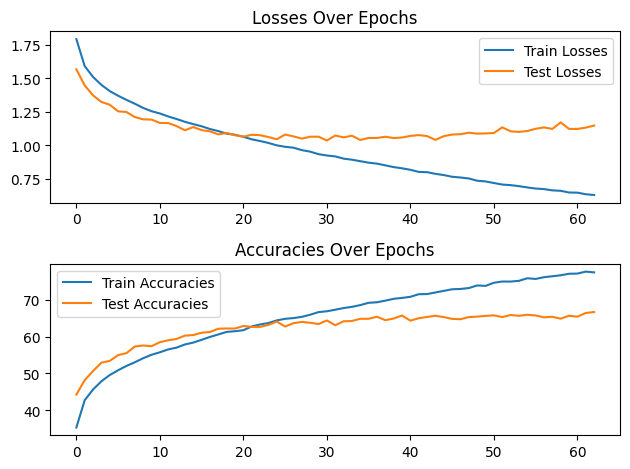

In [ ]:
import matplotlib.pyplot as plt

# Create subplots
plt.subplot(2, 1, 1)  # First subplot
plt.plot(train_losses, label='Train Losses')
plt.plot(test_losses, label='Test Losses')
plt.legend()
plt.title('Losses Over Epochs')

plt.subplot(2, 1, 2)  # Second subplot
plt.plot(train_accuracies, label='Train Accuracies')
plt.plot(test_accuracies, label='Test Accuracies')
plt.legend()
plt.title('Accuracies Over Epochs')

# Show the plot
plt.tight_layout()
plt.show()